# 01 — Cohort EDA

Sepsis-3 + adult + first ICU stay + LOS>=24h + got NE-equiv + NE start>intime + cum NE >= 1h.
Expected: **13,071 stays / 13,071 subjects** (first-stay-only guarantees 1:1).

All charts are aggregate-only — no patient identifiers printed or plotted.

## 0. Setup + load

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# Project root on sys.path so `from src...` works when run from notebooks/.
PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text

from src.cohort import load_cohort, compute_consort_flow
from src.db import get_engine

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

In [2]:
cohort = load_cohort(version='v1', use_cache=True)
print(f"Cohort shape: {cohort.shape}")
print(f"Unique stays: {cohort['stay_id'].nunique()}  subjects: {cohort['subject_id'].nunique()}")
cohort.dtypes

Cohort shape: (13071, 21)
Unique stays: 13071  subjects: 13071


subject_id                       int64
stay_id                          int64
hadm_id                          int64
intime                  datetime64[us]
outtime                 datetime64[us]
los                            float64
first_careunit                     str
age                            float64
gender                             str
dod                             object
race                               str
hospital_expire_flag             int64
deathtime               datetime64[us]
admittime               datetime64[us]
dischtime               datetime64[us]
sepsis3_onset_time      datetime64[us]
first_ne_time           datetime64[us]
last_ne_time            datetime64[us]
cum_ne_hours                   float64
peak_ne_equiv                  float64
first_day_sofa                   int64
dtype: object

## 1. Consort flow

In [3]:
consort = compute_consort_flow()
consort

,step,n_stays,n_subjects
0,1_sepsis3_all,41296,31911
1,2_adult_ge18,41296,31911
2,3_plus_los_ge_24h,37143,29320
3,4_first_icu_stay,29320,29320
4,5_got_ne_ever,14506,14506
5,6_ne_start_after_intime,13964,13964
6,7_cum_ne_hours_ge_1,13071,13071


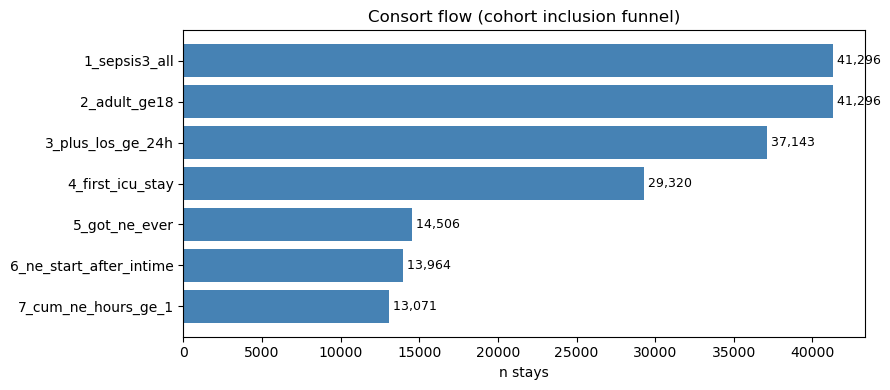

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(consort['step'], consort['n_stays'], color='steelblue')
for i, n in enumerate(consort['n_stays']):
    ax.text(n, i, f" {n:,}", va='center', fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('n stays')
ax.set_title('Consort flow (cohort inclusion funnel)')
plt.tight_layout()
plt.show()

## 2. Demographics

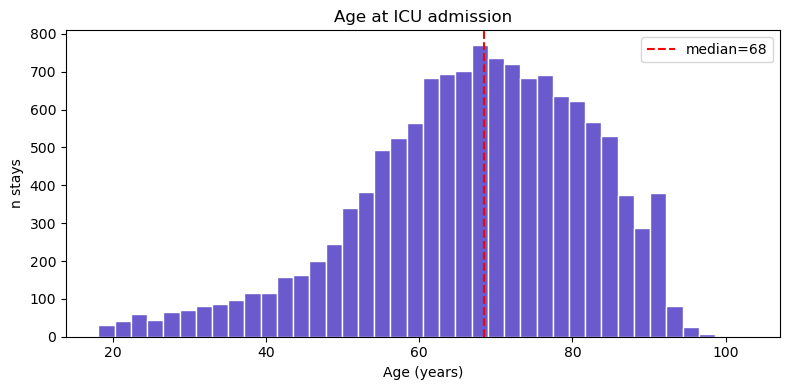

count    13071.0
mean        67.1
std         14.9
min         18.1
25%         58.2
50%         68.5
75%         78.2
max        102.9
Name: age, dtype: float64


In [5]:
# Age distribution. MIMIC caps extreme old ages at 91 (HIPAA).
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(cohort['age'].dropna(), bins=40, color='slateblue', edgecolor='white')
ax.axvline(cohort['age'].median(), color='red', linestyle='--', label=f"median={cohort['age'].median():.0f}")
ax.set_xlabel('Age (years)')
ax.set_ylabel('n stays')
ax.set_title('Age at ICU admission')
ax.legend()
plt.tight_layout()
plt.show()
print(cohort['age'].describe().round(1))

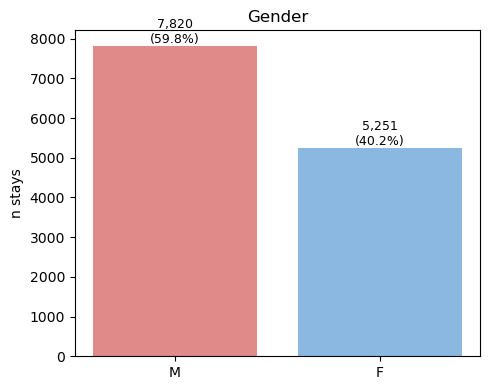

In [6]:
# Gender
g = cohort['gender'].fillna('Unknown').value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(g.index, g.values, color=['#e08a8a', '#8ab8e0', '#aaaaaa'][:len(g)])
for i, v in enumerate(g.values):
    ax.text(i, v, f"{v:,}\n({v/len(cohort)*100:.1f}%)", ha='center', va='bottom', fontsize=9)
ax.set_ylabel('n stays')
ax.set_title('Gender')
plt.tight_layout()
plt.show()

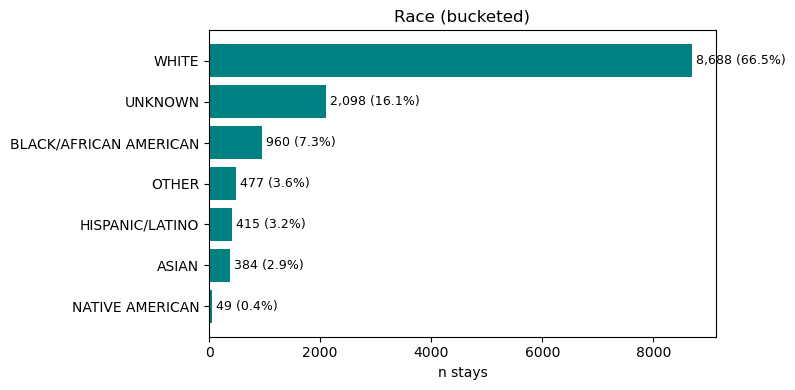

In [7]:
# Race (from admissions). Group sparse categories.
def _race_bucket(r: str) -> str:
    if not isinstance(r, str):
        return 'UNKNOWN'
    r = r.upper()
    if 'WHITE' in r: return 'WHITE'
    if 'BLACK' in r: return 'BLACK/AFRICAN AMERICAN'
    if 'HISPANIC' in r or 'LATINO' in r: return 'HISPANIC/LATINO'
    if 'ASIAN' in r: return 'ASIAN'
    if 'NATIVE' in r or 'AMERICAN INDIAN' in r: return 'NATIVE AMERICAN'
    if 'UNKNOWN' in r or 'UNABLE' in r or 'DECLINED' in r: return 'UNKNOWN'
    return 'OTHER'

race_bucket = cohort['race'].map(_race_bucket).value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(race_bucket.index[::-1], race_bucket.values[::-1], color='teal')
for i, v in enumerate(race_bucket.values[::-1]):
    ax.text(v, i, f" {v:,} ({v/len(cohort)*100:.1f}%)", va='center', fontsize=9)
ax.set_xlabel('n stays')
ax.set_title('Race (bucketed)')
plt.tight_layout()
plt.show()

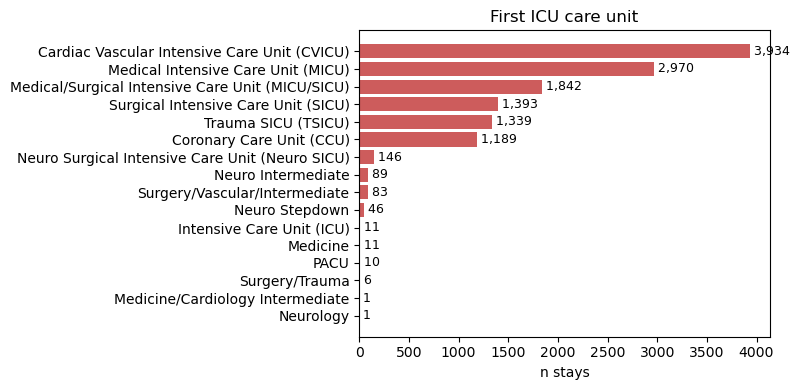

In [8]:
# First careunit
cu = cohort['first_careunit'].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(cu.index[::-1], cu.values[::-1], color='indianred')
for i, v in enumerate(cu.values[::-1]):
    ax.text(v, i, f" {v:,}", va='center', fontsize=9)
ax.set_xlabel('n stays')
ax.set_title('First ICU care unit')
plt.tight_layout()
plt.show()

## 3. SOFA distribution

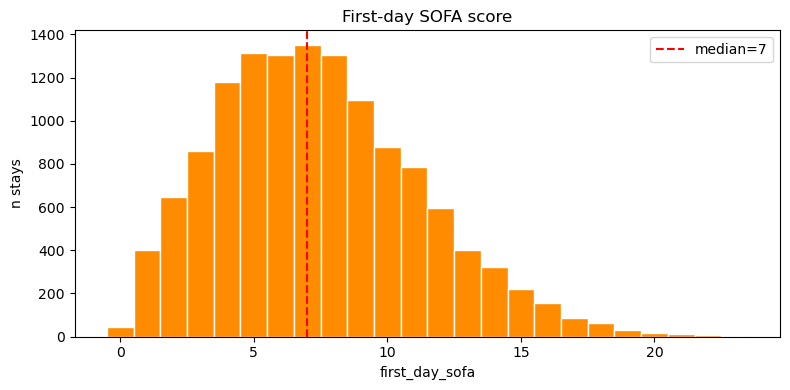

count    13071.00
mean         7.43
std          3.78
min          0.00
25%          5.00
50%          7.00
75%         10.00
max         23.00
Name: first_day_sofa, dtype: float64


In [9]:
if 'first_day_sofa' in cohort.columns and cohort['first_day_sofa'].notna().any():
    sofa = cohort['first_day_sofa'].dropna()
    fig, ax = plt.subplots(figsize=(8, 4))
    bins = np.arange(sofa.min(), sofa.max() + 2) - 0.5
    ax.hist(sofa, bins=bins, color='darkorange', edgecolor='white')
    ax.axvline(sofa.median(), color='red', linestyle='--', label=f'median={sofa.median():.0f}')
    ax.set_xlabel('first_day_sofa')
    ax.set_ylabel('n stays')
    ax.set_title('First-day SOFA score')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(sofa.describe().round(2))
else:
    print('first_day_sofa unavailable — check mimiciv_derived.first_day_sofa build.')

## 4. NE-equivalent usage patterns

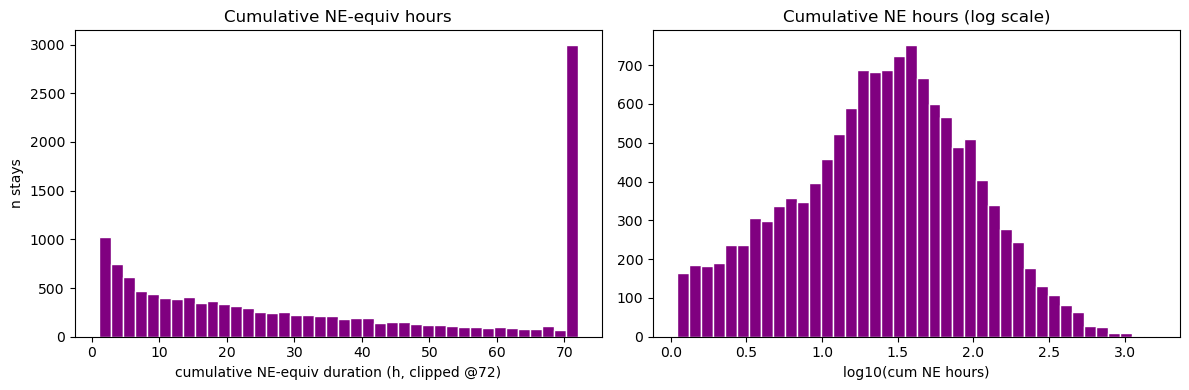

count    13071.00
mean        57.36
std         93.79
min          1.00
25%          9.80
50%         26.82
75%         64.76
max       1610.62
Name: cum_ne_hours, dtype: float64


In [10]:
# Cumulative NE-equivalent hours.
cum = cohort['cum_ne_hours'].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(cum.clip(upper=72), bins=40, color='purple', edgecolor='white')
axes[0].set_xlabel('cumulative NE-equiv duration (h, clipped @72)')
axes[0].set_ylabel('n stays')
axes[0].set_title('Cumulative NE-equiv hours')

axes[1].hist(np.log10(cum + 0.1), bins=40, color='purple', edgecolor='white')
axes[1].set_xlabel('log10(cum NE hours)')
axes[1].set_title('Cumulative NE hours (log scale)')
plt.tight_layout()
plt.show()
print(cum.describe().round(2))

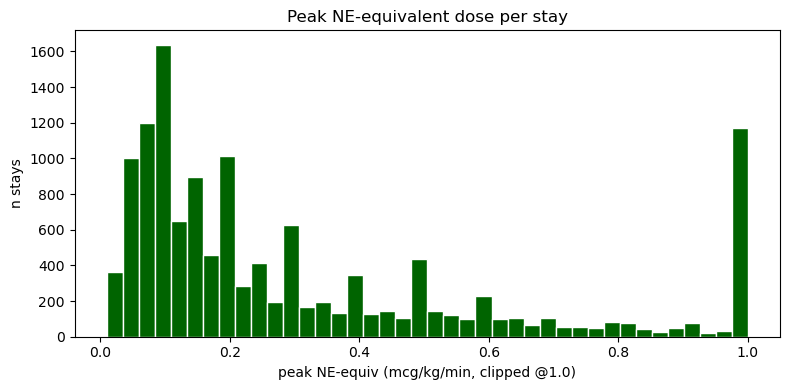

count    13071.0000
mean         0.6279
std          4.6148
min          0.0100
25%          0.1000
50%          0.2000
75%          0.4510
max        359.7007
Name: peak_ne_equiv, dtype: float64


In [11]:
# Peak NE-equivalent dose (mcg/kg/min)
if 'peak_ne_equiv' in cohort.columns and cohort['peak_ne_equiv'].notna().any():
    peak = cohort['peak_ne_equiv'].dropna()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(peak.clip(upper=1.0), bins=40, color='darkgreen', edgecolor='white')
    ax.set_xlabel('peak NE-equiv (mcg/kg/min, clipped @1.0)')
    ax.set_ylabel('n stays')
    ax.set_title('Peak NE-equivalent dose per stay')
    plt.tight_layout()
    plt.show()
    print(peak.describe().round(4))

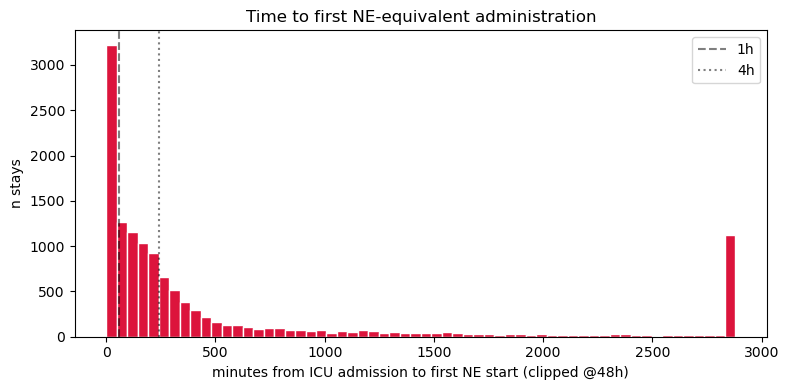

count    13071.0
mean       980.4
std       2757.0
min          0.0
25%         50.0
50%        185.4
75%        517.4
max      51461.0
dtype: float64


In [12]:
# Minutes from ICU intime to first NE start
mins = ((cohort['first_ne_time'] - cohort['intime']).dt.total_seconds() / 60.0).dropna()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(mins.clip(upper=2880), bins=60, color='crimson', edgecolor='white')
ax.axvline(60, color='black', linestyle='--', alpha=0.5, label='1h')
ax.axvline(240, color='black', linestyle=':', alpha=0.5, label='4h')
ax.set_xlabel('minutes from ICU admission to first NE start (clipped @48h)')
ax.set_ylabel('n stays')
ax.set_title('Time to first NE-equivalent administration')
ax.legend()
plt.tight_layout()
plt.show()
print(mins.describe().round(1))

## 5. Outcomes

In-hospital mortality: 0.231 (3,023 / 13,071)
28-day mortality: 0.248
90-day mortality: 0.311


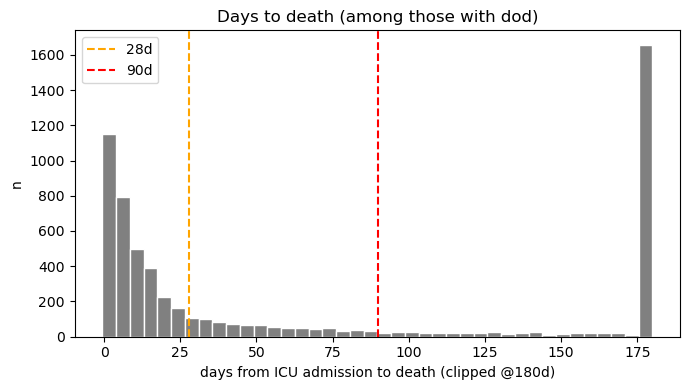

In [13]:
# In-hospital mortality
mort_in = cohort['hospital_expire_flag'].fillna(0).astype(int)
print(f"In-hospital mortality: {mort_in.mean():.3f} ({mort_in.sum():,} / {len(mort_in):,})")

# 28/90-day mortality from dod (patients.dod is date of death, if available)
if 'dod' in cohort.columns and cohort['dod'].notna().any():
    dod = pd.to_datetime(cohort['dod'])
    intime = pd.to_datetime(cohort['intime'])
    days_to_death = (dod - intime).dt.total_seconds() / 86400.0
    mort_28 = ((days_to_death >= 0) & (days_to_death <= 28)).mean()
    mort_90 = ((days_to_death >= 0) & (days_to_death <= 90)).mean()
    print(f"28-day mortality: {mort_28:.3f}")
    print(f"90-day mortality: {mort_90:.3f}")

    fig, ax = plt.subplots(figsize=(7, 4))
    dtd_clip = days_to_death.dropna().clip(upper=180)
    ax.hist(dtd_clip, bins=40, color='gray', edgecolor='white')
    ax.axvline(28, color='orange', linestyle='--', label='28d')
    ax.axvline(90, color='red', linestyle='--', label='90d')
    ax.set_xlabel('days from ICU admission to death (clipped @180d)')
    ax.set_ylabel('n')
    ax.set_title('Days to death (among those with dod)')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('dod column empty — cannot compute 28/90-day mortality.')

## 6. Data availability sanity — 4h-bin coverage

For a random sample of stays, compute what fraction of 4-hour bins in the first 72h have at least one lactate measurement, MAP vital, and ventilator setting. Gives a rough prior for feature sparsity.

In [14]:
SAMPLE_N = 500  # random sample to keep the query cheap
rng = np.random.default_rng(42)
sample_ids = rng.choice(cohort['stay_id'].to_numpy(), size=min(SAMPLE_N, len(cohort)), replace=False).tolist()

engine = get_engine()

def _avail_by_bin(table: str, time_col: str, value_col: str, label: str, join_key: str = 'stay') -> pd.Series:
    # vitalsign has stay_id (join_key='stay'); bg has only subject_id+hadm_id (join_key='subject_hadm').
    if join_key == 'stay':
        join_clause = 'JOIN mimiciv_icu.icustays i ON i.stay_id = t.stay_id'
        where_clause = 'WHERE t.stay_id = ANY(:stay_ids)'
    else:
        join_clause = 'JOIN mimiciv_icu.icustays i ON i.subject_id = t.subject_id AND i.hadm_id = t.hadm_id'
        where_clause = 'WHERE i.stay_id = ANY(:stay_ids)'
    q = text(f"""
        SELECT i.stay_id,
               FLOOR(EXTRACT(EPOCH FROM (t.{time_col} - i.intime)) / 3600.0 / 4.0)::int AS bin4h,
               COUNT(t.{value_col}) AS n
        FROM {table} t
        {join_clause}
        {where_clause}
          AND t.{time_col} >= i.intime
          AND t.{time_col} < i.intime + INTERVAL '72 hours'
        GROUP BY i.stay_id, bin4h
    """)
    df_ = pd.read_sql(q, engine, params={'stay_ids': sample_ids})
    by_stay = df_.groupby('stay_id')['bin4h'].nunique()
    frac = by_stay.reindex(sample_ids, fill_value=0) / 18.0
    print(f"{label}: mean 4h-bin coverage = {frac.mean():.3f}  median = {frac.median():.3f}")
    return frac

# vitalsign has MAP (joined via stay_id). bg has lactate (joined via subject+hadm).
cov_vitals = _avail_by_bin('mimiciv_derived.vitalsign', 'charttime', 'mbp', 'vitals MAP', join_key='stay')
cov_lactate = _avail_by_bin('mimiciv_derived.bg', 'charttime', 'lactate', 'lactate', join_key='subject_hadm')

vitals MAP: mean 4h-bin coverage = 0.868  median = 1.000
lactate: mean 4h-bin coverage = 0.339  median = 0.278


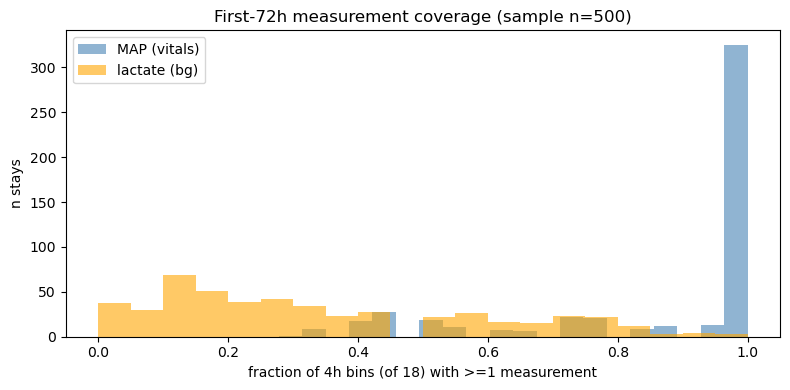

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(cov_vitals, bins=20, alpha=0.6, label='MAP (vitals)', color='steelblue')
ax.hist(cov_lactate, bins=20, alpha=0.6, label='lactate (bg)', color='orange')
ax.set_xlabel('fraction of 4h bins (of 18) with >=1 measurement')
ax.set_ylabel('n stays')
ax.set_title(f'First-72h measurement coverage (sample n={len(sample_ids)})')
ax.legend()
plt.tight_layout()
plt.show()

---

**Next steps** (features-agent):
- 4h-bin state tensor: vitals + bg/chem/cbc + SOFA + ventilation flag
- ffill + cohort-mean imputation, z-score using train-fold stats
- Action bins: `0`, `(0, 8.4]`, `(8.4, 20.28]`, `(20.28, 50]`, `>50` NE-equiv mcg/min
